# Divar Real Estate — Tehran Apartment Sale Price Analysis

A clean, end-to-end pipeline: scope and load the data, clean and engineer features
(including several Persian-language / Jalali-calendar parsing fixes), explore the
market, and compare price prediction models — with an honest look at where the
model breaks down.

**Segment:** `residential-sell` / `apartment-sell` / Tehran


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42

## 1. Load and Scope the Data

Filter to a single, coherent segment before doing anything else. Rent, sale, and
credit-value listings follow different pricing logics — mixing them conflates the
target variable. A time-based split (rather than random) is used so evaluation
reflects real forecasting conditions.

In [4]:
DATA_PATH = r"C:\Users\Thinkpad\Desktop\divar_price\real_estate_ads.csv"

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw shape: {df_raw.shape}")

Raw shape: (1000000, 60)


In [5]:
SEGMENT_CAT2 = "residential-sell"
SEGMENT_CAT3 = "apartment-sell"
SEGMENT_CITY = "tehran"

mask = (
    (df_raw['cat2_slug'] == SEGMENT_CAT2) &
    (df_raw['cat3_slug'] == SEGMENT_CAT3) &
    (df_raw['city_slug'] == SEGMENT_CITY)
)
df = df_raw.loc[mask].copy()
print(f"Filtered shape: {df.shape}  ({mask.mean():.1%} of raw rows)")

Filtered shape: (84586, 60)  (8.5% of raw rows)


In [6]:
df['created_at_month'] = pd.to_datetime(df['created_at_month'], errors='coerce')
print("Date range:", df['created_at_month'].min(), "to", df['created_at_month'].max())

Date range: 2020-02-01 00:00:00 to 2025-02-01 00:00:00


In [7]:
TEST_MONTHS = 3  # hold out the last N months as the test set

cutoff_date = df['created_at_month'].max() - pd.DateOffset(months=TEST_MONTHS)
train_df = df[df['created_at_month'] <= cutoff_date].copy()
test_df = df[df['created_at_month'] > cutoff_date].copy()

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Cutoff date: 2024-11-01
Train: 72,529 rows | Test: 12,057 rows


## 2. Clean and Engineer Features

All cleaning parameters (clip bounds, medians, encodings) are fit on the **training
set only** and applied to test, to avoid leaking future information backward.

### 2.1 Drop columns that don't apply to this segment

In [8]:
missing_pct = train_df.isna().mean().sort_values(ascending=False) * 100
fully_missing_cols = missing_pct[missing_pct == 100.0].index.tolist()

print(f"Dropping {len(fully_missing_cols)} fully-missing columns (belong to other cat2/cat3 segments):")
print(fully_missing_cols)

train_df = train_df.drop(columns=fully_missing_cols)
test_df = test_df.drop(columns=[c for c in fully_missing_cols if c in test_df.columns])

Dropping 29 fully-missing columns (belong to other cat2/cat3 segments):
['rent_mode', 'rent_value', 'rent_to_single', 'rent_type', 'transformable_rent', 'transformed_rent', 'transformed_credit', 'transformable_credit', 'rent_credit_transform', 'transformable_price', 'credit_mode', 'credit_value', 'land_size', 'has_business_deed', 'has_jacuzzi', 'has_pool', 'regular_person_capacity', 'property_type', 'cost_per_extra_person', 'extra_person_capacity', 'rent_price_at_weekends', 'rent_price_on_special_days', 'rent_price_on_regular_days', 'has_sauna', 'has_water', 'has_electricity', 'has_gas', 'has_security_guard', 'has_barbecue']


### 2.2 Drop invalid target rows

In [9]:
TARGET = "price_value"

def drop_invalid_target(df, target=TARGET):
    before = len(df)
    out = df[df[target].notna() & (df[target] > 0)].copy()
    print(f"Dropped {before - len(out):,} rows with invalid/missing {target}")
    return out

train_df = drop_invalid_target(train_df)
test_df = drop_invalid_target(test_df)

Dropped 2 rows with invalid/missing price_value
Dropped 0 rows with invalid/missing price_value


### 2.3 Parse Persian-language and Jalali-calendar fields

Three fields needed special handling that a generic `pd.to_numeric` can't do on its own:

- **`rooms_count`** is stored as Persian *words* (`یک`, `دو`, `سه`...), not digits — needs a category map.
- **`floor` / `unit_per_floor`** use Persian-Indic digits (۰۱۲۳...) — needs digit translation.
- **`construction_year`** uses Persian-Indic digits *and* the Jalali (Solar Hijri) calendar — needs digit translation **and** calendar conversion, or building-age calculations will be off by roughly 621 years.

In [10]:
persian_digits = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')

def parse_persian_number(val):
    """Convert a Persian-Indic digit string to a Western numeric value."""
    if pd.isna(val):
        return np.nan
    s = str(val).translate(persian_digits).strip()
    return pd.to_numeric(s, errors='coerce')

rooms_map = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5,   # "5 or more" — collapses larger apartments into one bucket
}

def parse_jalali_to_gregorian_year(val):
    """Persian-Indic Jalali year -> approximate Gregorian year (+621, year-level only).
    For exact conversion, use the `jdatetime` library instead."""
    jalali_year = parse_persian_number(val)
    if pd.isna(jalali_year):
        return np.nan
    return jalali_year + 621

for d in (train_df, test_df):
    d['rooms_count'] = d['rooms_count'].map(rooms_map)
    d['floor'] = d['floor'].apply(parse_persian_number)
    d['unit_per_floor'] = d['unit_per_floor'].apply(parse_persian_number)
    d['construction_year'] = d['construction_year'].apply(parse_jalali_to_gregorian_year)

print(train_df[['rooms_count', 'floor', 'unit_per_floor', 'construction_year']].describe())

       rooms_count     floor  unit_per_floor  construction_year
count    72,526.00 72,477.00       47,881.00          71,653.00
mean          1.93      3.21            2.24           2,013.83
std           0.75      2.75            1.38               7.81
min           0.00     -1.00            1.00           1,992.00
25%           1.00      2.00            1.00           2,007.00
50%           2.00      3.00            2.00           2,015.00
75%           2.00      4.00            3.00           2,021.00
max           5.00     30.00            8.00           2,024.00


### 2.4 Handle `user_type`

Missing is not random here: only a small share of listings are confirmed
individual sellers, so missing values are encoded as their own `"unknown"`
category rather than imputed toward either class — imputing would manufacture
a signal that isn't actually in the data.

In [11]:
train_df['user_type'] = train_df['user_type'].fillna('unknown')
test_df['user_type'] = test_df['user_type'].fillna('unknown')

print(train_df['user_type'].value_counts())
print(f"\nProportions:\n{train_df['user_type'].value_counts(normalize=True).round(3)}")

user_type
مشاور املاک    35877
unknown        35514
شخصی            1136
Name: count, dtype: int64

Proportions:
user_type
مشاور املاک   0.49
unknown       0.49
شخصی          0.02
Name: proportion, dtype: float64


### 2.5 Outlier clipping

Asking-price data has fat tails (typos, placeholder values, genuine luxury
outliers). Percentile bounds are fit on train and applied to both sets.

In [12]:
CLIP_COLS = ["price_value", "building_size"]
LOWER_Q, UPPER_Q = 0.01, 0.99

clip_bounds = {}
for col in CLIP_COLS:
    lo, hi = train_df[col].quantile([LOWER_Q, UPPER_Q])
    clip_bounds[col] = (lo, hi)
    print(f"{col}: clipping to [{lo:,.0f}, {hi:,.0f}]")

for col, (lo, hi) in clip_bounds.items():
    train_df[col] = train_df[col].clip(lo, hi)
    test_df[col] = test_df[col].clip(lo, hi)  # train-derived bounds applied to test, never refit

price_value: clipping to [111,111,111, 88,000,000,000]
building_size: clipping to [37, 300]


### 2.6 Impute remaining missing values

Numeric structural fields use the train median. Boolean amenity flags use
`False` — missing almost always means "not mentioned," not "unknown".

In [13]:
NUMERIC_IMPUTE_COLS = ["rooms_count", "floor", "unit_per_floor", "construction_year", "building_size"]
BOOLEAN_COLS = [c for c in train_df.columns if c.startswith("has_")]

medians = {}
for col in NUMERIC_IMPUTE_COLS:
    med = train_df[col].median()
    medians[col] = med
    train_df[col] = train_df[col].fillna(med)
    test_df[col] = test_df[col].fillna(med)  # train median applied to test

for col in BOOLEAN_COLS:
    train_df[col] = train_df[col].fillna(False).astype(bool)
    test_df[col] = test_df[col].fillna(False).astype(bool)

print("Imputed medians (from train):", medians)
print("Boolean amenity columns:", BOOLEAN_COLS)

Imputed medians (from train): {'rooms_count': np.float64(2.0), 'floor': np.float64(3.0), 'unit_per_floor': np.float64(2.0), 'construction_year': np.float64(2015.0), 'building_size': np.float64(82.0)}
Boolean amenity columns: ['has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom']


### 2.7 Engineer derived features

In [14]:
def engineer_features(df):
    df = df.copy()

    df['price_per_sqm'] = np.where(df['building_size'] > 0, df[TARGET] / df['building_size'], np.nan)

    listing_year = df['created_at_month'].dt.year
    df['building_age'] = (listing_year - df['construction_year']).clip(lower=0)

    df['amenity_count'] = df[BOOLEAN_COLS].sum(axis=1)

    df['floor_ratio'] = np.where(df['unit_per_floor'] > 0, df['floor'] / df['unit_per_floor'], np.nan)

    return df

train_df = engineer_features(train_df)
test_df = engineer_features(test_df)

train_df[['price_per_sqm', 'building_age', 'amenity_count', 'floor_ratio']].describe()

,price_per_sqm,building_age,amenity_count,floor_ratio
count,"72,527.00","72,527.00","72,527.00","72,527.00"
mean,"99,297,518.28",10.16,5.71,1.68
std,"71,552,491.33",7.76,2.34,1.38
min,"370,370.37",0.00,0.00,-1.00
25%,"58,400,000.00",3.00,3.00,1.00
50%,"84,558,823.53",9.00,7.00,1.50
75%,"120,915,032.68",17.00,8.00,2.00
max,"2,378,378,378.38",32.00,8.00,30.00


### 2.8 Encode neighborhood (target encoding) and seller type (one-hot)

`neighborhood_slug` has hundreds of unique values — target encoding (mean
`price_per_sqm` by neighborhood, fit on train) avoids the dimensionality blowup
of one-hot encoding. Unseen neighborhoods in test fall back to the city-wide mean.

In [15]:
city_wide_mean = train_df['price_per_sqm'].mean()
neighborhood_encoding = train_df.groupby('neighborhood_slug')['price_per_sqm'].mean()

train_df['neighborhood_price_encoding'] = train_df['neighborhood_slug'].map(neighborhood_encoding)
test_df['neighborhood_price_encoding'] = test_df['neighborhood_slug'].map(neighborhood_encoding).fillna(city_wide_mean)

print(f"Unique neighborhoods in train: {train_df['neighborhood_slug'].nunique()}")

train_df = pd.get_dummies(train_df, columns=['user_type'], prefix='user_type')
test_df = pd.get_dummies(test_df, columns=['user_type'], prefix='user_type')
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

Unique neighborhoods in train: 343


### 2.9 Sanity check and save

In [16]:
amenity_cols = [c for c in train_df.columns if c.startswith('has_')]
user_type_cols = [c for c in train_df.columns if c.startswith('user_type_')]

MODEL_FEATURE_COLS = [
    'building_size', 'rooms_count', 'floor', 'unit_per_floor', 'building_age',
    'amenity_count', 'floor_ratio', 'neighborhood_price_encoding'
] + amenity_cols + user_type_cols

remaining_nulls = train_df[MODEL_FEATURE_COLS + [TARGET]].isna().sum()
print("Remaining nulls in modeling columns:")
print(remaining_nulls[remaining_nulls > 0])

import os
os.makedirs("data/processed", exist_ok=True)
train_df.to_parquet("data/processed/train_clean.parquet", index=False)
test_df.to_parquet("data/processed/test_clean.parquet", index=False)
print(f"\nSaved train_clean.parquet {train_df.shape} and test_clean.parquet {test_df.shape}")

Remaining nulls in modeling columns:
Series([], dtype: int64)

Saved train_clean.parquet (72527, 38) and test_clean.parquet (12057, 38)


## 3. Exploratory Analysis

### 3.1 Price distributions

Raw price is right-skewed; log-price is closer to normal, which is why the model
in Section 4 predicts log(price) rather than raw price.

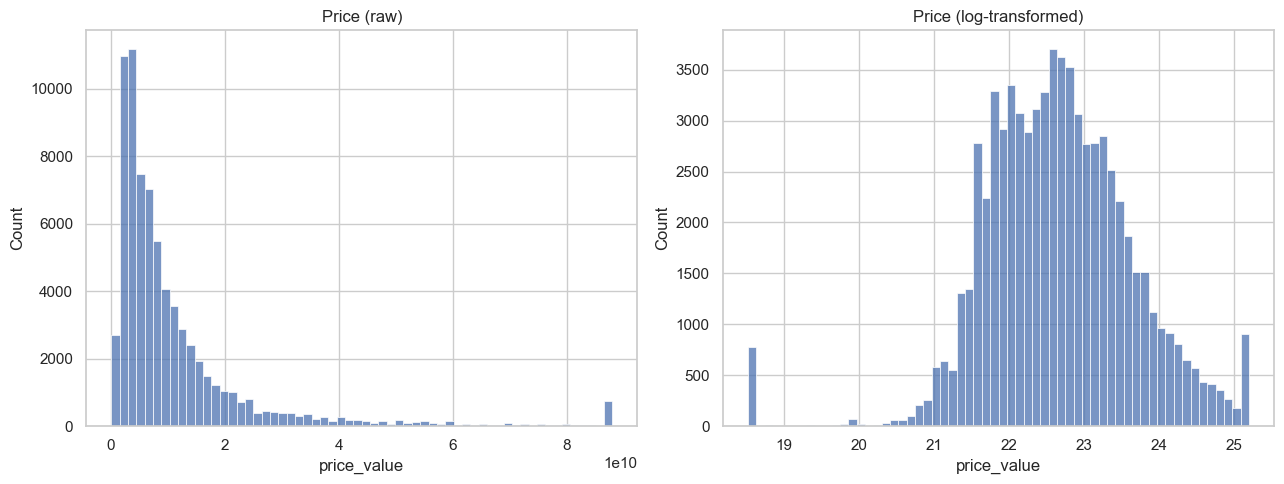

            price_value    price_per_sqm
count         72,527.00        72,527.00
mean  11,221,287,241.18    99,297,518.28
std   13,836,999,209.18    71,552,491.33
min      111,111,111.00       370,370.37
25%    3,570,000,000.00    58,400,000.00
50%    6,700,000,000.00    84,558,823.53
75%   12,800,000,000.00   120,915,032.68
max   88,000,000,000.00 2,378,378,378.38


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(train_df['price_value'], bins=60, ax=axes[0])
axes[0].set_title('Price (raw)')
sns.histplot(np.log1p(train_df['price_value']), bins=60, ax=axes[1])
axes[1].set_title('Price (log-transformed)')
plt.tight_layout()
plt.show()

print(train_df[['price_value', 'price_per_sqm']].describe())

### 3.2 Amenities and price premium

Compares median price-per-sqm for listings with vs. without each amenity.

In [18]:
amenity_summary = []
for col in amenity_cols:
    with_a = train_df.loc[train_df[col] == True, 'price_per_sqm'].median()
    without_a = train_df.loc[train_df[col] == False, 'price_per_sqm'].median()
    amenity_summary.append({
        'amenity': col,
        'prevalence_pct': round(train_df[col].mean() * 100, 1),
        'median_with': with_a,
        'median_without': without_a,
        'pct_premium': round((with_a / without_a - 1) * 100, 1) if without_a else np.nan,
    })

amenity_df = pd.DataFrame(amenity_summary).sort_values('pct_premium', ascending=False)
amenity_df

,amenity,prevalence_pct,median_with,median_without,pct_premium
3,has_parking,80.50,"95,982,142.86","57,980,196.08",65.50
1,has_elevator,75.20,"98,130,841.12","61,120,071.68",60.60
2,has_warehouse,89.90,"89,090,909.09","61,538,461.54",44.80
0,has_balcony,69.00,"83,870,967.74","85,714,285.71",-2.20
7,has_restroom,67.00,"83,333,333.33","86,885,245.90",-4.10
5,has_heating_system,63.20,"81,818,181.82","89,411,764.71",-8.50
4,has_warm_water_provider,62.50,"81,746,031.75","89,686,630.67",-8.90
6,has_cooling_system,63.80,"81,818,181.82","89,973,958.33",-9.10


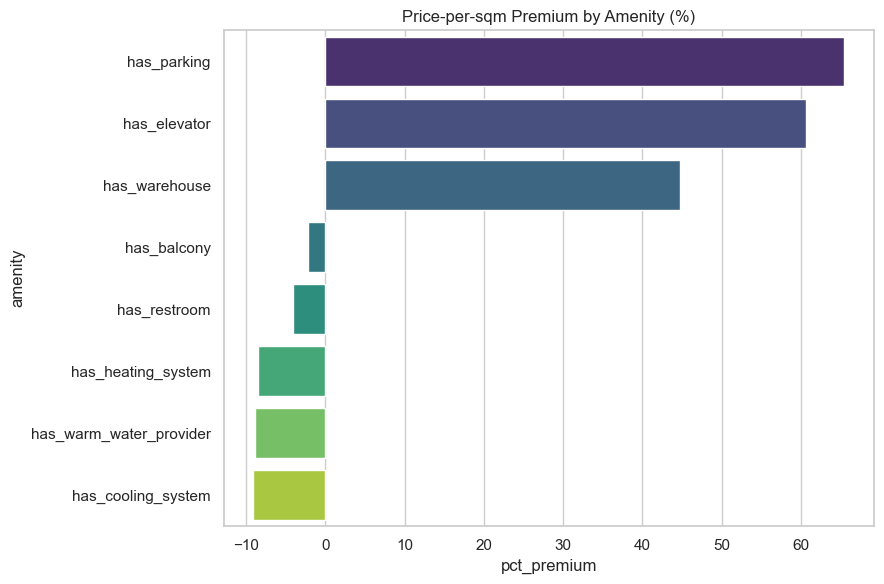

In [19]:
plt.figure(figsize=(9, 6))
sns.barplot(data=amenity_df, x='pct_premium', y='amenity', hue='amenity', legend=False, palette='viridis')
plt.title('Price-per-sqm Premium by Amenity (%)')
plt.tight_layout()
plt.show()

### 3.3 Price trend over time

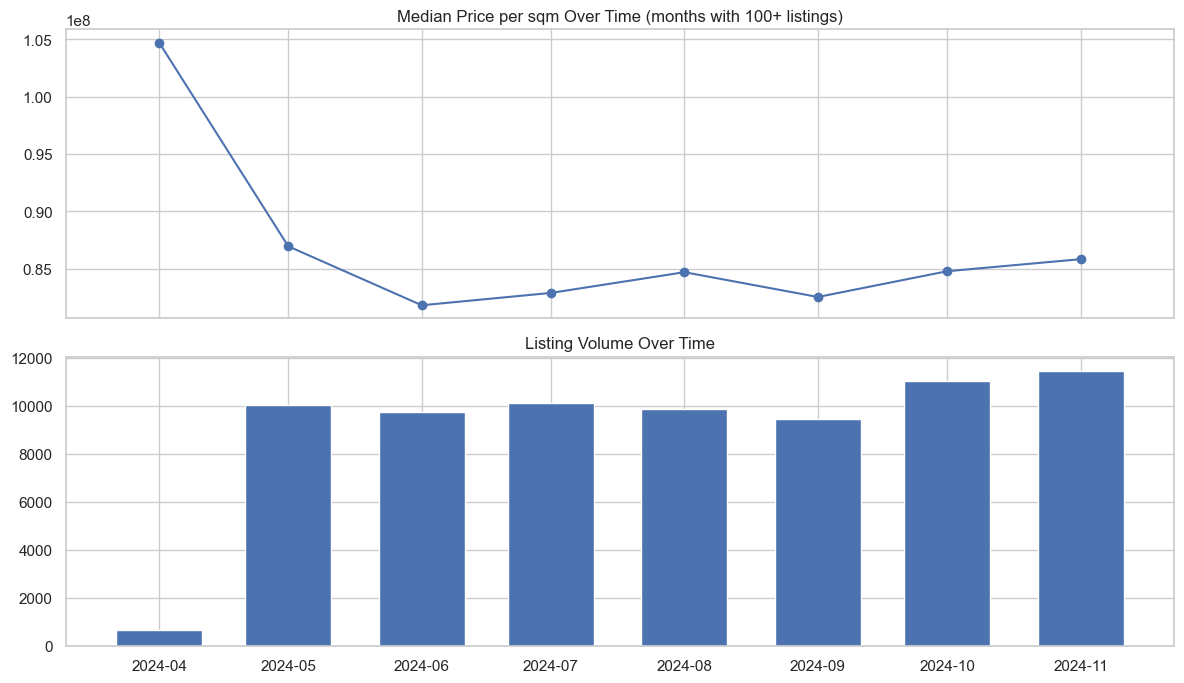

In [20]:
monthly = train_df.groupby(train_df['created_at_month'].dt.to_period('M')).agg(
    median_price_per_sqm=('price_per_sqm', 'median'),
    listing_count=('price_value', 'count')
).reset_index()
monthly['created_at_month'] = monthly['created_at_month'].dt.to_timestamp()

MIN_LISTINGS = 100  # adjust based on what you consider reliable

monthly_filtered = monthly[monthly['listing_count'] >= MIN_LISTINGS]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly_filtered['created_at_month'], monthly_filtered['median_price_per_sqm'], marker='o')
axes[0].set_title(f'Median Price per sqm Over Time (months with {MIN_LISTINGS}+ listings)')
axes[1].bar(monthly_filtered['created_at_month'], monthly_filtered['listing_count'], width=20)
axes[1].set_title('Listing Volume Over Time')
plt.tight_layout()
plt.show()

### 3.4 Individual vs. agency listings

Recall `user_type` is heavily imbalanced (few confirmed individual sellers) —
treat this comparison as suggestive, not conclusive.

In [21]:
user_type_cat = train_df[user_type_cols].idxmax(axis=1).str.replace('user_type_', '', regex=False)

comparison = train_df.assign(user_type_cat=user_type_cat).groupby('user_type_cat').agg(
    n_listings=('price_value', 'count'),
    median_price=('price_value', 'median'),
    median_price_per_sqm=('price_per_sqm', 'median'),
)
comparison

,n_listings,median_price,median_price_per_sqm
user_type_cat,,,
unknown,35514,"6,000,000,000.00","77,272,727.27"
شخصی,1136,"5,250,000,000.00","70,000,000.00"
مشاور املاک,35877,"7,600,000,000.00","92,608,695.65"


## 4. Build and Compare Models

Baseline linear regression → Random Forest → XGBoost, all predicting
log-transformed price, evaluated on the time-based holdout.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

X_train = train_df[MODEL_FEATURE_COLS].copy()
X_test = test_df[MODEL_FEATURE_COLS].copy()
for col in amenity_cols + user_type_cols:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

y_train = np.log1p(train_df[TARGET])
y_test = np.log1p(test_df[TARGET])

print(f"{len(MODEL_FEATURE_COLS)} features | NaNs in X_train: {X_train.isna().sum().sum()}")

19 features | NaNs in X_train: 0


In [23]:
results = {}

def evaluate_model(name, model):
    preds_log = model.predict(X_test)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))
    r2 = r2_score(y_test, preds_log)

    preds_real = np.expm1(preds_log)
    actual_real = np.expm1(y_test)
    mae_real = mean_absolute_error(actual_real, preds_real)

    results[name] = {'R2 (log)': r2, 'RMSE (log)': rmse_log, 'MAE (toman)': mae_real}
    print(f"{name}: R2={r2:.3f} | RMSE(log)={rmse_log:.3f} | MAE(toman)={mae_real:,.0f}")
    return preds_log, preds_real

lr_model = LinearRegression().fit(X_train, y_train)
lr_preds_log, lr_preds_real = evaluate_model('Linear Regression', lr_model)

rf_model = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=5,
                                  random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
rf_preds_log, rf_preds_real = evaluate_model('Random Forest', rf_model)

xgb_model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=RANDOM_STATE, n_jobs=-1)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
xgb_preds_log, xgb_preds_real = evaluate_model('XGBoost', xgb_model)

Linear Regression: R2=0.426 | RMSE(log)=0.820 | MAE(toman)=5,603,917,291
Random Forest: R2=0.589 | RMSE(log)=0.694 | MAE(toman)=3,114,900,846
XGBoost: R2=0.590 | RMSE(log)=0.692 | MAE(toman)=3,277,396,914


In [24]:
results_df = pd.DataFrame(results).T.sort_values('R2 (log)', ascending=False)
results_df

,R2 (log),RMSE (log),MAE (toman)
XGBoost,0.59,0.69,"3,277,396,914.28"
Random Forest,0.59,0.69,"3,114,900,845.96"
Linear Regression,0.43,0.82,"5,603,917,290.65"


### 4.1 Feature importance (SHAP)

Using XGBoost — swap `best_model` below if Random Forest is preferred (it had
a marginally lower toman MAE despite a near-identical R²).

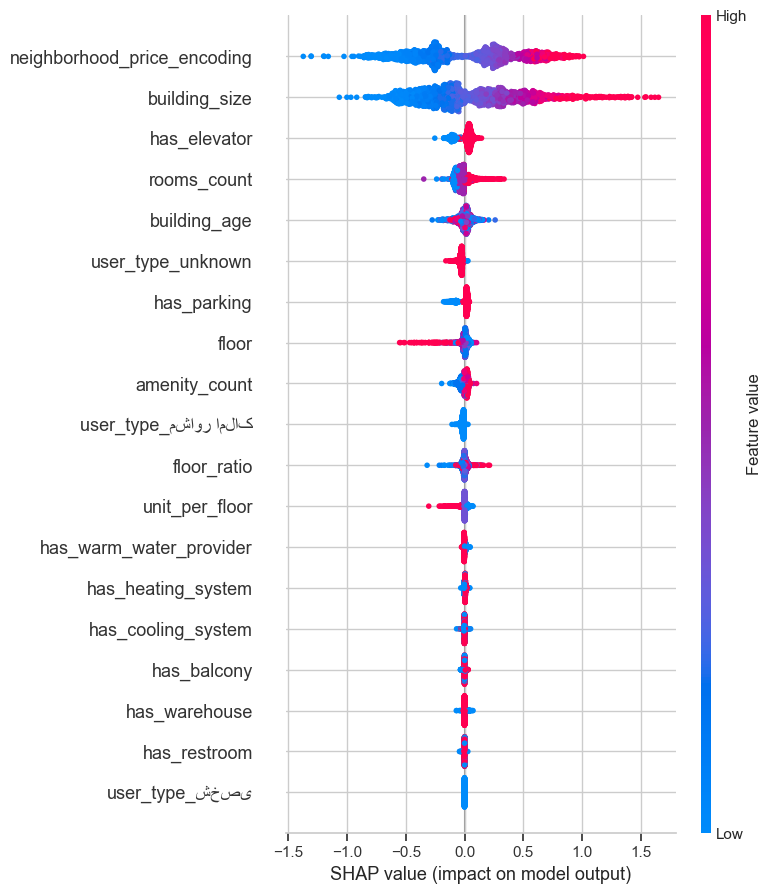

In [25]:
import shap

best_model = xgb_model
best_preds_real = xgb_preds_real

explainer = shap.TreeExplainer(best_model)
sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, show=True)

### 4.2 Residual analysis

Where does the model systematically over/under-predict? Breaking residuals down
by neighborhood is the most important diagnostic here — it's what reveals whether
the model generalizes evenly across the market or fails on specific segments.

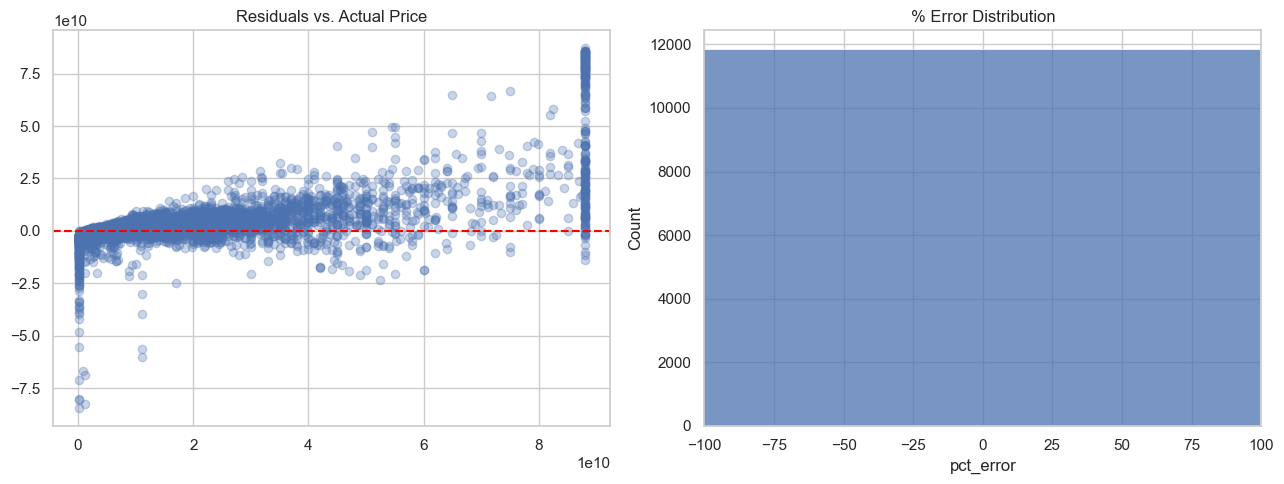

Worst-predicted neighborhoods (min 10 listings):
                      n  mean_abs_pct_error
neighborhood_slug                          
jamaran              14            2,532.36
aghdasieh            47            2,323.79
hekmat               34            1,663.66
velenjak             84            1,418.97
elahiyeh             95            1,415.80
zafaraniyeh         139            1,362.88
jordan               42            1,357.37
hasan-abad-shomali   36            1,213.81
tehran-jolfa         19            1,096.38
dezashib             23            1,081.73


In [26]:
actual_real = np.expm1(y_test)
residuals = actual_real.values - best_preds_real

residual_df = test_df[['building_size', 'neighborhood_slug']].copy()
residual_df['actual'] = actual_real.values
residual_df['predicted'] = best_preds_real
residual_df['pct_error'] = (residual_df['actual'] - residual_df['predicted']) / residual_df['actual'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(residual_df['actual'], residual_df['actual'] - residual_df['predicted'], alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs. Actual Price')
sns.histplot(residual_df['pct_error'], bins=60, ax=axes[1])
axes[1].set_title('% Error Distribution')
axes[1].set_xlim(-100, 100)
plt.tight_layout()
plt.show()

neighborhood_error = residual_df.groupby('neighborhood_slug').agg(
    n=('pct_error', 'count'),
    mean_abs_pct_error=('pct_error', lambda x: x.abs().mean())
)
print("Worst-predicted neighborhoods (min 10 listings):")
print(neighborhood_error[neighborhood_error['n'] >= 10].sort_values('mean_abs_pct_error', ascending=False).head(10))

> **Note:** if the worst-predicted neighborhoods turn out to be Tehran's
> established high-end addresses (as in the original run of this analysis), that's
> a genuine finding worth foregrounding in a write-up — it means the model's
> reliable range excludes the luxury segment, where price is likely driven by
> unobserved factors (specific address prestige, finish quality) rather than the
> structural features available here.

### 4.3 Save model artifacts

In [27]:
import joblib
os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/price_model.pkl")
joblib.dump(MODEL_FEATURE_COLS, "models/feature_cols.pkl")
joblib.dump(neighborhood_encoding, "models/neighborhood_encoding.pkl")
print("Saved model, feature list, and neighborhood encoding to models/")

Saved model, feature list, and neighborhood encoding to models/
